## Interest Rate Volatility Term Structure Prediction

This project predicts the volatility term structure of interest rates by tenor (2Y / 5Y / 10Y / 30Y) at a 5-day horizon. The notebook decomposes realized volatility across tenors using PCA into three orthogonal components (level / slope / curvature), then trains independent regression models — Lasso as a linear baseline and Gradient Boosting as the main model — for each component.

The pipeline is validated using a walk-forward, and the predicted PCA scores are inverted back into a full reconstructed vol curve across tenors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
import yfinance as yf
from fredapi import Fred
from dotenv import load_dotenv
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from scipy import stats

In [2]:
# Parameters and config
load_dotenv()
FRED_API_KEY = os.getenv('FRED_API_KEY')
START_DATE   = '2005-01-01'
RANDOM_STATE = 42
HORIZON      = 20
N_SPLITS     = 10
DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

### 1. Data Collection

#### 1.1. Data Sources

Three data sources are used:

- **FRED API** — U.S. Treasury yields (2Y / 5Y / 10Y / 30Y), Fed Funds Rate, 5Y breakeven inflation
- **Yahoo Finance** — MOVE Index, VIX index, Option IV Skew
- **FRED API** — Moody's Baa corporate spread over 10Y Treasury, proxy for credit risk

In [3]:
# FRED
FRED_PATH = f'{DATA_DIR}/fred_data.csv'
df_fred = pd.read_csv(FRED_PATH, index_col='date', parse_dates=True)
df_fred['fedfunds'] = df_fred['fedfunds'].ffill()
df_fred = df_fred.ffill(limit=5)

# Yahoo finance
YF_PATH = f'{DATA_DIR}/yf_data.csv'
df_yf = pd.read_csv(YF_PATH, index_col='date', parse_dates=True)

# HY spread
HY_PATH = f'{DATA_DIR}/baa_spread.csv'
df_hy = pd.read_csv(HY_PATH, index_col='date', parse_dates=True)

# Merg cells
df = df_fred.join(df_yf, how='inner').join(df_hy, how='inner')
df = df.dropna()

print('=' * 50 + '\n DATASET OVERVIEW:\n' + '=' * 50)
print(f'  Period         : {df.index.min().date()}  to  {df.index.max().date()}')
print(f'  Observations   : {len(df)}')

 DATASET OVERVIEW:
  Period         : 2005-01-03  to  2026-05-28
  Observations   : 5227


#### 1.2. U.S. Rates by Tenor (2005–present)

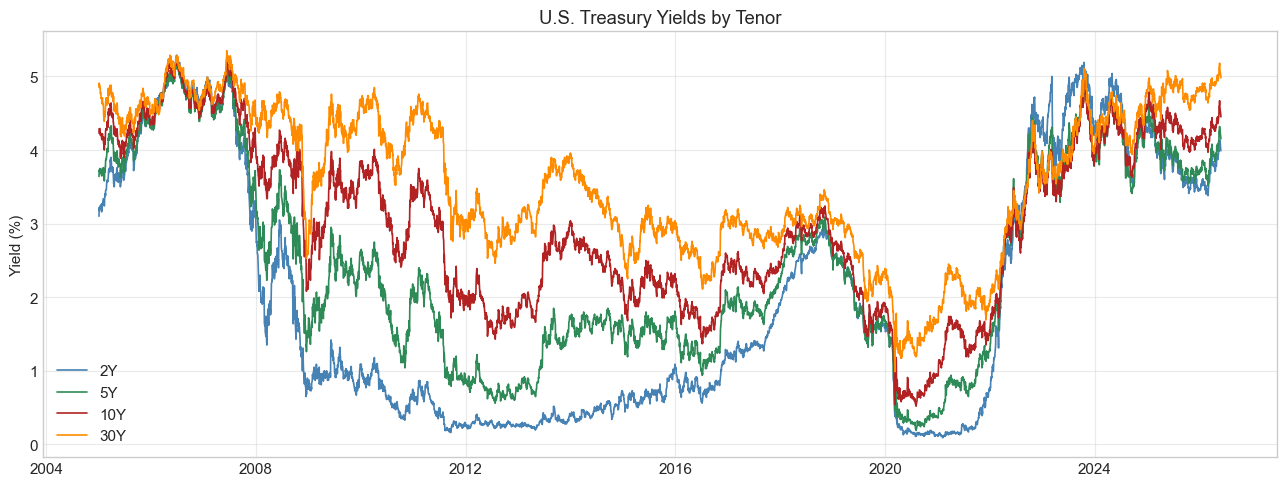

In [4]:
# Plot
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['steelblue', 'seagreen', 'firebrick', 'darkorange']
for col, color, label in zip(
    ['rate_2Y', 'rate_5Y', 'rate_10Y', 'rate_30Y'], colors, ['2Y', '5Y', '10Y', '30Y']
):
    ax.plot(df.index, df[col], color=color, lw=1.2, label=label)

ax.set_title('U.S. Treasury Yields by Tenor')
ax.set_ylabel('Yield (%)')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

#### 1.3. MOVE Index — Implied Rate Volatility (2005–present)

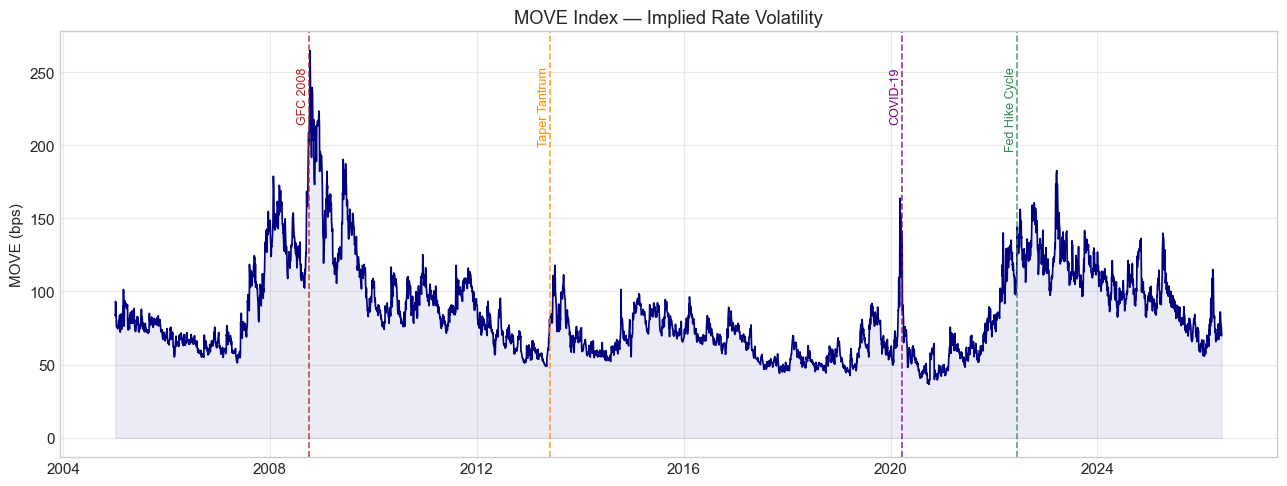

In [5]:
# Plot
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df['MOVE'], color='navy', lw=1.2)
ax.fill_between(df.index, df['MOVE'], alpha=0.08, color='navy')

events = [
    ('2008-10-01', 'GFC 2008',       'firebrick'),
    ('2013-06-01', 'Taper Tantrum',  'darkorange'),
    ('2020-03-20', 'COVID-19',       'purple'),
    ('2022-06-15', 'Fed Hike Cycle', 'seagreen'),
]
for date, label, color in events:
    idx = df.index.searchsorted(pd.Timestamp(date))
    x   = df.index[min(idx, len(df) - 1)]
    ax.axvline(x, color=color, lw=1.2, linestyle='--', alpha=0.8)
    ax.text(x, df['MOVE'].max() * 0.96, label, color=color,
            fontsize=9, rotation=90, va='top', ha='right')

ax.set_title('MOVE Index — Implied Rate Volatility')
ax.set_ylabel('MOVE (bps)')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### 2. Realized Volatility and PCA

We construct realized volatility proxies for each tenor as the 20-day rolling standard deviation of daily yield changes. This is particularly relevant in the context of IR derivatives.

These four series compose the target matrix for the PCA. Litterman & Scheinkman (1991) showed that three factors (level, slope, curvature) explain >99% of yield curve variance. We
expect the same structure to emerge from the rate volatility term structure.

#### 2.1. Realized Volatility By Tenor

 REALIZED VOL SUMMARY:
          vol_2Y     vol_5Y    vol_10Y    vol_30Y
count  5207.0000  5207.0000  5207.0000  5207.0000
mean      0.0435     0.0540     0.0534     0.0513
std       0.0284     0.0247     0.0209     0.0191
min       0.0079     0.0128     0.0193     0.0206
25%       0.0231     0.0361     0.0384     0.0379
50%       0.0375     0.0483     0.0485     0.0475
75%       0.0541     0.0657     0.0628     0.0594
max       0.2168     0.1941     0.1451     0.1747


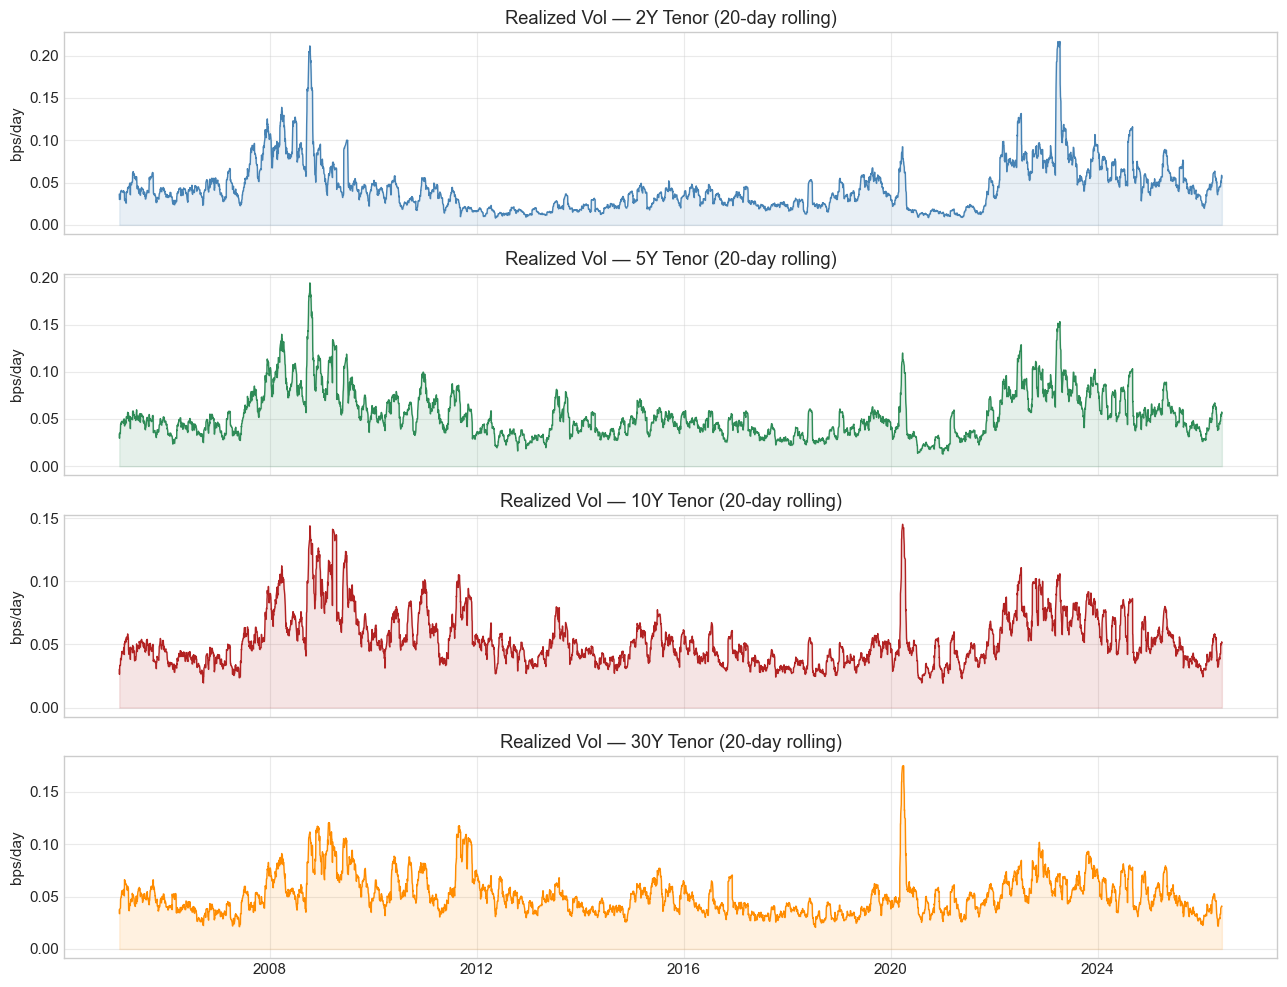

In [6]:
# Realized volatility series
for col, name in [
    ('rate_2Y',  'vol_2Y'),
    ('rate_5Y',  'vol_5Y'),
    ('rate_10Y', 'vol_10Y'),
    ('rate_30Y', 'vol_30Y'),
]:
    df[name] = df[col].diff().rolling(20).std()

VOL_COLS = ['vol_2Y', 'vol_5Y', 'vol_10Y', 'vol_30Y']

print('=' * 50 + '\n REALIZED VOL SUMMARY:\n' + '=' * 50)
print(df[VOL_COLS].describe().round(4).to_string())

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

# Plot
for ax, col, color, label in zip(
    axes, VOL_COLS, ['steelblue', 'seagreen', 'firebrick', 'darkorange'],
    ['2Y', '5Y', '10Y', '30Y']
):
    ax.plot(df.index, df[col], color=color, lw=1.0)
    ax.fill_between(df.index, df[col], alpha=0.12, color=color)
    ax.set_title(f'Realized Vol — {label} Tenor (20-day rolling)')
    ax.set_ylabel('bps/day')
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

#### 2.2. PCA Decomposition

In [7]:
# Variable standardisation
vol_matrix = df[VOL_COLS].dropna()
scaler_pca = StandardScaler()
vol_scaled = scaler_pca.fit_transform(vol_matrix)

# PCA on the vol matrix
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(vol_scaled)
df_pca = pd.DataFrame(pca_scores, index=vol_matrix.index, columns=['PC1', 'PC2', 'PC3'])
pca_ev = pca.explained_variance_ratio_

print('=' * 50 + '\n PCA EXPLAINED VARIANCE:\n' + '=' * 50)
print(f'  PC1 : {pca_ev[0]*100:.1f}%')
print(f'  PC2 : {pca_ev[1]*100:.1f}%')
print(f'  PC3 : {pca_ev[2]*100:.1f}%')
print(f'  Cumulative (3 PCs) : {pca_ev.sum()*100:.1f}%')

 PCA EXPLAINED VARIANCE:
  PC1 : 82.0%
  PC2 : 15.7%
  PC3 : 1.9%
  Cumulative (3 PCs) : 99.7%


#### 2.3. PCA Loadings — Economic Interpretation

 PCA LOADINGS:
        PC1     PC2     PC3
2Y   0.4538  0.6945  0.5153
5Y   0.5355  0.2296 -0.5204
10Y  0.5343 -0.2666 -0.4011
30Y  0.4710 -0.6276  0.5502


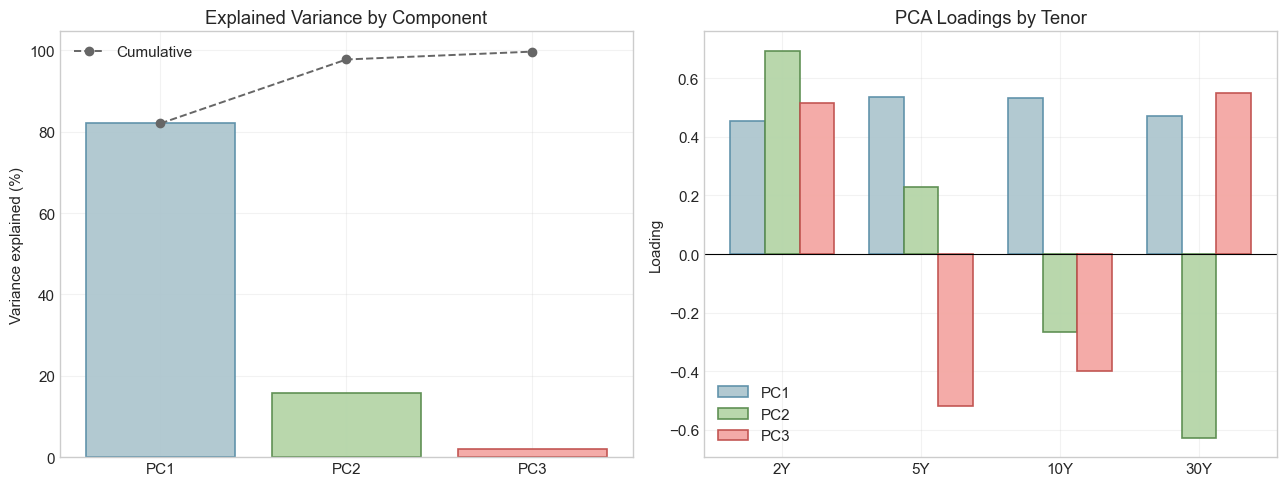

In [48]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=['2Y', '5Y', '10Y', '30Y'],
    columns=['PC1', 'PC2', 'PC3']
)

print('=' * 50 + '\n PCA LOADINGS:\n' + '=' * 50)
print(pca_loadings.round(4).to_string())

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors  = ['#aec6cf', '#b5d5a8', '#f4a7a3']
border_colors  = ['#5b8fa8', '#5a8c4e', '#c0504d']  

ax1.bar(['PC1', 'PC2', 'PC3'], pca_ev * 100,
        color=colors, edgecolor=border_colors, linewidth=1.2, alpha=0.95)
ax1.plot(['PC1', 'PC2', 'PC3'], np.cumsum(pca_ev) * 100, 'o--',
         color='#666666', lw=1.4, label='Cumulative')
ax1.set_title('Explained Variance by Component')
ax1.set_ylabel('Variance explained (%)')
ax1.legend()
ax1.grid(alpha=0.25)

x = np.arange(len(pca_loadings))
width = 0.25
for i, (col, fill, edge) in enumerate(zip(['PC1', 'PC2', 'PC3'], colors, border_colors)):
    ax2.bar(x + i * width, pca_loadings[col], width, label=col,
            color=fill, edgecolor=edge, linewidth=1.2, alpha=0.95)
ax2.set_xticks(x + width)
ax2.set_xticklabels(['2Y', '5Y', '10Y', '30Y'])
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('PCA Loadings by Tenor')
ax2.set_ylabel('Loading')
ax2.legend()
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Loading interpretation** 
- PC1: shows uniformly positive loadings across all tenors, represning a parallel volatility level shift. When PC1 rises, all tenor vols rise together.
- PC2: exhibits a monotone pattern of positive short tenors loading and negative long tenors loading. It effectively captures the slope of the vol curve.
- PC3: has positive loading for short and long-term rates and negative for medium-term rates. It captures the convexity of the rates volatility term structure.

This three-factor decomposition directly relates to interest rate derivatives. For example, a PC1 shock affects all the vega buckets exposure.

#### 2.4. Data Validation — PC1 vs. MOVE Index

To validate the economic interpretation of the PC1 target, we check if the realized rate volatility level is correlated to the implied volatility (MOVE index).

In [9]:
corr_pc1_move = df_pca['PC1'].corr(df['MOVE'].reindex(df_pca.index))

print('=' * 50 + '\n EXTERNAL VALIDATION:\n' + '=' * 50)
print(f'  Corr(PC1, MOVE Index) : {corr_pc1_move:.3f}')
print(f'  → {"Strong" if abs(corr_pc1_move) > 0.7 else "Moderate"} alignment between PC1 and MOVE')

 EXTERNAL VALIDATION:
  Corr(PC1, MOVE Index) : 0.871
  → Strong alignment between PC1 and MOVE


#### 2.5. Target Construction

The targets are the PCA score levels at t+20: $\text{PC1}_{tar}(t) = \text{PC1}(t+20)$, where PC1 is derived from the 20-day realized volatility window from $t+1$ to $t+20$. This is forward-looking: we try to predict the volatility of the term structure characteristics over the next month.

Also, we use the persistence baseline as comparison. It predicts that $\text{PC1}(t+20) = \text{PC1}(t)$: this is traditional matringale process. Beating it means our features contains information beyond the current term structure values.


In [10]:
# Target: PC level at t+20 — forward 20-day realized vol, zero overlap
for col in ['PC1', 'PC2', 'PC3']:
    df_pca[f'{col}_target'] = df_pca[col].shift(-HORIZON)

print(f'  Targets: PC1_target, PC2_target, PC3_target')

  Targets: PC1_target, PC2_target, PC3_target


### 3. Feature Engineering

#### 3.1. Feature Construction

Features are grouped into seven economic blocks:

- **Yield curve structure:** level and slope of rates (drivers of PC1 and PC2)
- **Realized volatility:** rolling vol by tenor and the short/long vol ratio (driver of vol regime)
- **Market sentiment:** VIX and SKEW as proxies for market fear and tail-risk
- **Monetary policy & macro:** Fed Funds, 5Y inflation breakeven, credit spread
- **Mean-reversion z-scores:** distance of PC scores and market variables from their 6M rolling mean to capture mean-reversion dynamics
- **Persistence lags:** PC values at t-5 and t-20 to infer momentum and persistence from the recent trajectory
- **HAR structure (Corsi, 2009):** daily, weekly (5d), and monthly (22d) averages of each PC score, replicating the Heterogeneous Autoregressive model of Realized Volatility — the benchmark model in the realized vol literature. The intuition is that market participants operate at different horizons: intraday traders react to daily vol, portfolio managers to weekly, institutional investors to monthly. The HAR features capture this multi-horizon persistence directly on the PCA scores.

In [11]:
# first group
df['slope_2_10']    = df['rate_10Y'] - df['rate_2Y']
df['slope_5_30']    = df['rate_30Y'] - df['rate_5Y']
df['level_10Y']     = df['rate_10Y']
df['change_10Y_5d'] = df['rate_10Y'].diff(5)

# second group
df['rvol_10Y_20d'] = df['rate_10Y'].diff().rolling(20).std()
df['rvol_2Y_20d']  = df['rate_2Y'].diff().rolling(20).std()
df['rvol_ratio']   = df['rvol_2Y_20d'] / df['rvol_10Y_20d']

# sixth group
df['d_slope_5d']   = df['slope_2_10'].diff(5)
df['d_slope_20d']  = df['slope_2_10'].diff(20)
df['change_2Y_5d'] = df['rate_2Y'].diff(5)
df['rel_move_5d']  = df['change_2Y_5d'] - df['change_10Y_5d']
df['fed_lag']      = df['fedfunds'] - df['rate_2Y']

# z-scores
WINDOW_MR = 180
def zscore(series, window):
    mu  = series.rolling(window).mean()
    sig = series.rolling(window).std()
    return (series - mu) / sig

# fifth group
df['VIX_zscore']   = zscore(df['VIX'], WINDOW_MR)
df['MOVE_zscore']  = zscore(df['MOVE'], WINDOW_MR)
df['slope_zscore'] = zscore(df['slope_2_10'], WINDOW_MR)

# PC-based features: lags, z-scores, and HAR structure (all built before df_model)
for pc in ['PC1', 'PC2', 'PC3']:
    pc_series = df_pca[pc].reindex(df.index)

    # persistence lags
    df[f'{pc}_lag']   = pc_series
    df[f'{pc}_lag5']  = pc_series.shift(5)
    df[f'{pc}_lag20'] = pc_series.shift(20)

    # mean-reversion z-score
    df[f'{pc}_zscore'] = zscore(pc_series, WINDOW_MR)

    # seventh group — HAR (Heterogeneous Autoregressive) features (Corsi, 2009)
    # Daily, weekly (5d) and monthly (22d) averages of each PC score
    # Captures multi-horizon persistence: intraday traders (d), portfolio managers (w), institutions (m)
    df[f'{pc}_har_d'] = pc_series.shift(1)                   # yesterday
    df[f'{pc}_har_w'] = pc_series.shift(1).rolling(5).mean() # past week avg
    df[f'{pc}_har_m'] = pc_series.shift(1).rolling(22).mean()# past month avg

FEATURES = [
    'slope_2_10', 'slope_5_30', 'level_10Y', 'change_10Y_5d',
    'rvol_10Y_20d', 'rvol_2Y_20d', 'rvol_ratio',
    'VIX', 'SKEW', 'MOVE',
    'fedfunds', 'breakeven_5Y', 'baa_spread',
    'd_slope_5d', 'd_slope_20d', 'rel_move_5d', 'fed_lag',
    'VIX_zscore', 'MOVE_zscore', 'slope_zscore',
    'PC1_zscore', 'PC2_zscore', 'PC3_zscore',
    'PC1_lag', 'PC2_lag', 'PC3_lag',
    'PC1_lag5', 'PC2_lag5', 'PC3_lag5',
    'PC1_lag20', 'PC2_lag20', 'PC3_lag20',
    'PC1_har_d', 'PC2_har_d', 'PC3_har_d',
    'PC1_har_w', 'PC2_har_w', 'PC3_har_w',
    'PC1_har_m', 'PC2_har_m', 'PC3_har_m',
]

TARGETS = ['PC1_target', 'PC2_target', 'PC3_target']

df_model = df[FEATURES].join(df_pca[TARGETS], how='inner').dropna()

print('=' * 50 + '\n MODEL DATASET:\n' + '=' * 50)
print(f'  Observations : {len(df_model)}')
print(f'  Features     : {len(FEATURES)}')
print(f'  Period       : {df_model.index.min().date()}  to  {df_model.index.max().date()}')


 MODEL DATASET:
  Observations : 5008
  Features     : 41
  Period       : 2005-10-18  to  2026-04-29


#### 3.2. Feature Correlation with Targets

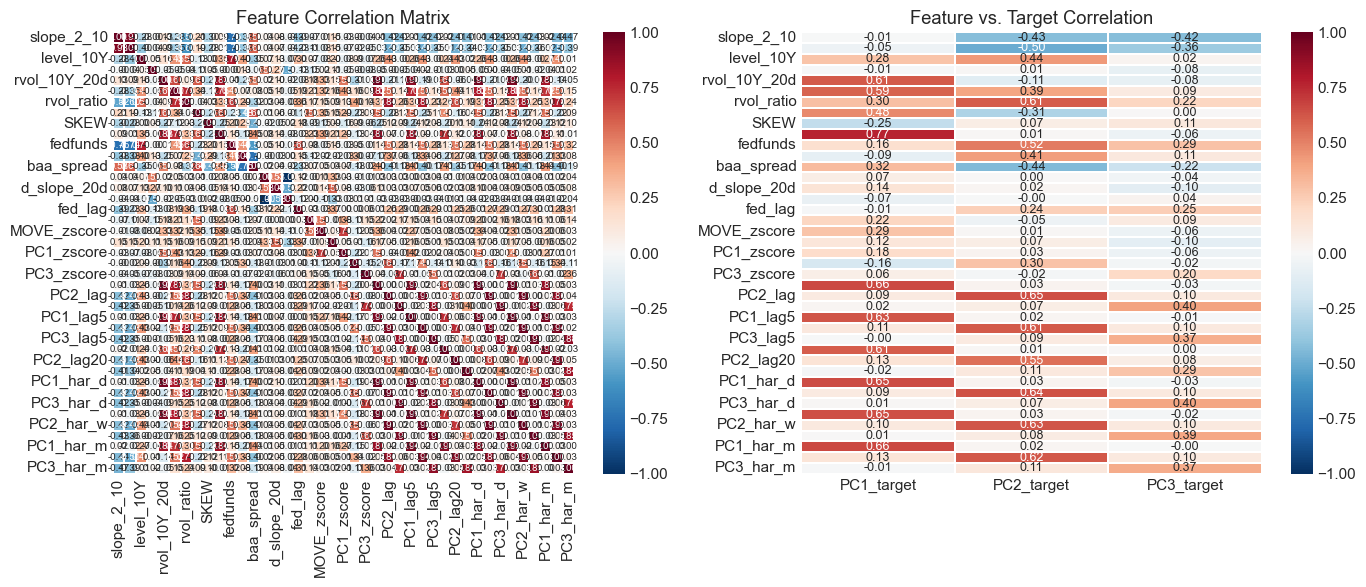

In [12]:
# Feature and target correlation matrices
feat_corr = df_model[FEATURES].corr()
target_corr = df_model[FEATURES + TARGETS].corr().loc[FEATURES, TARGETS]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(feat_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.3, annot_kws={'size': 7})
axes[0].set_title('Feature Correlation Matrix')

sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1], linewidths=0.3, annot_kws={'size': 9})
axes[1].set_title('Feature vs. Target Correlation')

plt.tight_layout()
plt.show()

#### 3.3. PCA Targets Distributions

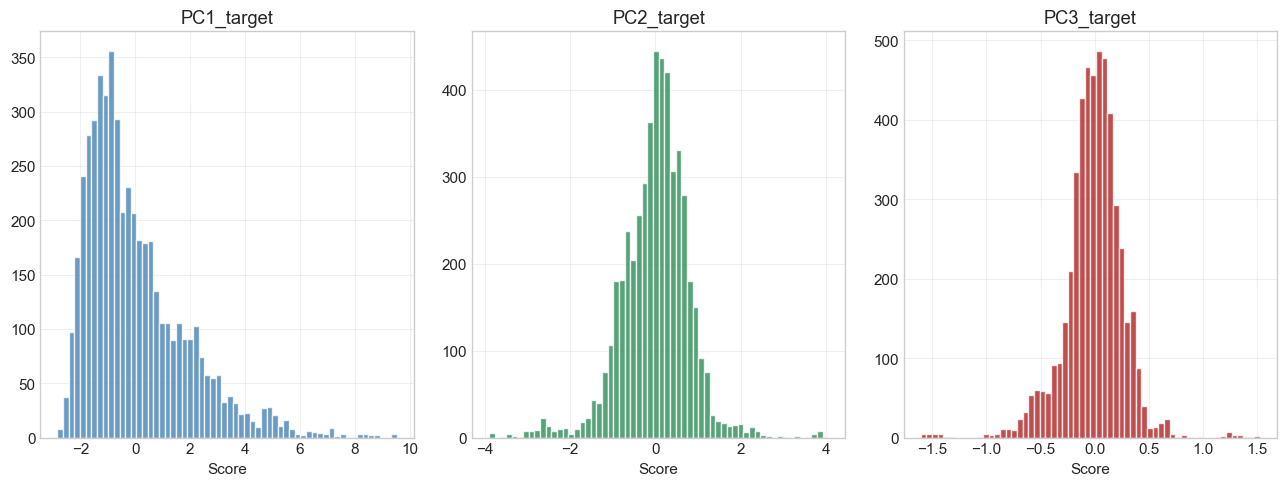

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, target, color in zip(axes, TARGETS, ['steelblue', 'seagreen', 'firebrick']):
    ax.hist(df_model[target], bins=60, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{target}')
    ax.set_xlabel('Score')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Data Processing: Train and Test Split

To train our model, we need to split the time series data. We use an 80/20 chronological split. The test set covers the most recent 20% of observations, preserving the temporal ordering to avoid look-ahead bias.

Model selection and hyperparameter tuning use cross-validation within the training set, ensuring that each validation fold only uses information available at that point in time.

In [14]:
split_idx  = int(len(df_model) * 0.8)
train      = df_model.iloc[:split_idx]
test       = df_model.iloc[split_idx:]

X_train    = train[FEATURES]
X_test     = test[FEATURES]

print('=' * 50 + '\n TRAIN - TEST SPLIT:\n' + '=' * 50)
print(f'  Train : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} obs)')
print(f'  Test  : {test.index.min().date()}  → {test.index.max().date()}   ({len(test)} obs)')

 TRAIN - TEST SPLIT:
  Train : 2005-10-18 → 2022-03-07  (4006 obs)
  Test  : 2022-03-08  → 2026-04-29   (1002 obs)


### 5. Model 1: Elastic Net Regression

Elastic Net combines L1 (Lasso) and L2 (Ridge) penalties. The L1 ratio parameter $\rho$ controls the mix: $\rho$=1 is pure Lasso and $\rho$=0 is pure Ridge. Cross-validation jointly selects both $\alpha$ and $\rho$ using 5-fold. The selected $\rho$ is itself informative: if CV picks 1, L1 alone suffices. A lower value indicates multi-collinearity in the features.

#### 5.1. Fitting Model

In [15]:
results_enet = {}
tscv_inner   = TimeSeriesSplit(n_splits=5)

for target in TARGETS:
    y_train = train[target]
    y_test  = test[target]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_train)
    X_te_sc = sc.transform(X_test)

    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=tscv_inner, max_iter=10000, random_state=RANDOM_STATE
    )
    enet.fit(X_tr_sc, y_train)

    y_pred_tr = enet.predict(X_tr_sc)
    y_pred_te = enet.predict(X_te_sc)

    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred_te))
    mae_te  = mean_absolute_error(y_test, y_pred_te)
    coefs   = pd.Series(enet.coef_, index=FEATURES)

    results_enet[target] = {
        'alpha': enet.alpha_, 'l1_ratio': enet.l1_ratio_,
        'rmse_train': rmse_tr, 'rmse_test': rmse_te,
        'mae_test': mae_te, 'coefs': coefs, 'scaler': sc,
        'y_pred_test': y_pred_te, 'model': enet,
    }

    print(f'--- {target} ---')
    print(f'  Alpha optimal      : {enet.alpha_:.4f}')
    print(f'  L1 ratio           : {enet.l1_ratio_:.2f}')
    print(f'  RMSE train         : {rmse_tr:.4f}')
    print(f'  RMSE test          : {rmse_te:.4f}')
    print(f'  MAE test           : {mae_te:.4f}')
    print(f'  Non-zero features  : {(coefs != 0).sum()}/{len(FEATURES)}')

--- PC1_target ---
  Alpha optimal      : 0.2243
  L1 ratio           : 1.00
  RMSE train         : 1.1496
  RMSE test          : 1.3987
  MAE test           : 1.0270
  Non-zero features  : 1/41
--- PC2_target ---
  Alpha optimal      : 0.1210
  L1 ratio           : 0.50
  RMSE train         : 0.5415
  RMSE test          : 0.6620
  MAE test           : 0.4377
  Non-zero features  : 11/41
--- PC3_target ---
  Alpha optimal      : 0.0155
  L1 ratio           : 1.00
  RMSE train         : 0.2350
  RMSE test          : 0.2469
  MAE test           : 0.1907
  Non-zero features  : 12/41


#### 5.2. Elastic Net Coefficients

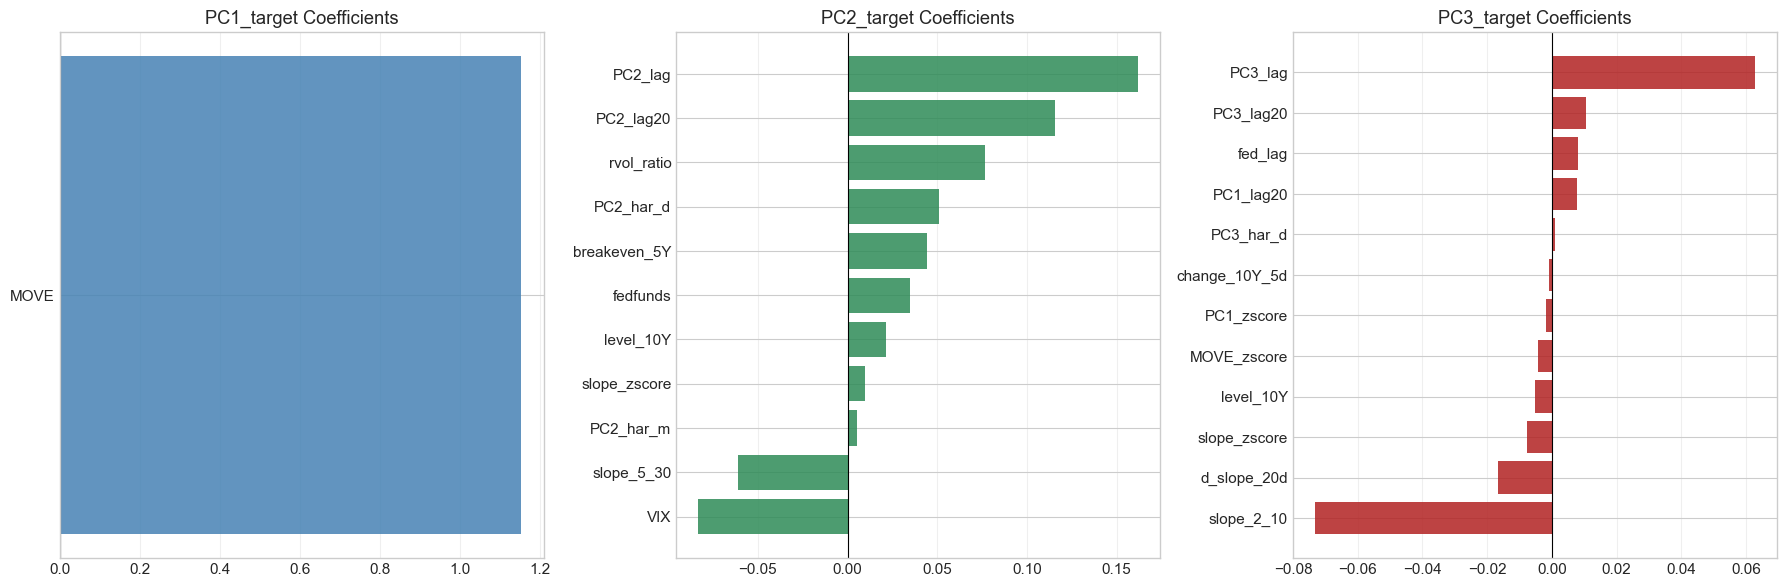

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, target, color in zip(axes, TARGETS, ['steelblue', 'seagreen', 'firebrick']):
    coefs = results_enet[target]['coefs'].sort_values().fillna(0).dropna()
    coefs_clean = coefs[coefs.abs() >= 1e-6]
    l1r   = results_enet[target]['l1_ratio']
    ax.barh(coefs_clean.index, coefs_clean.values, color=color, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{target} Coefficients')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

#### 5.3. Elastic Net Predictions vs. Realized

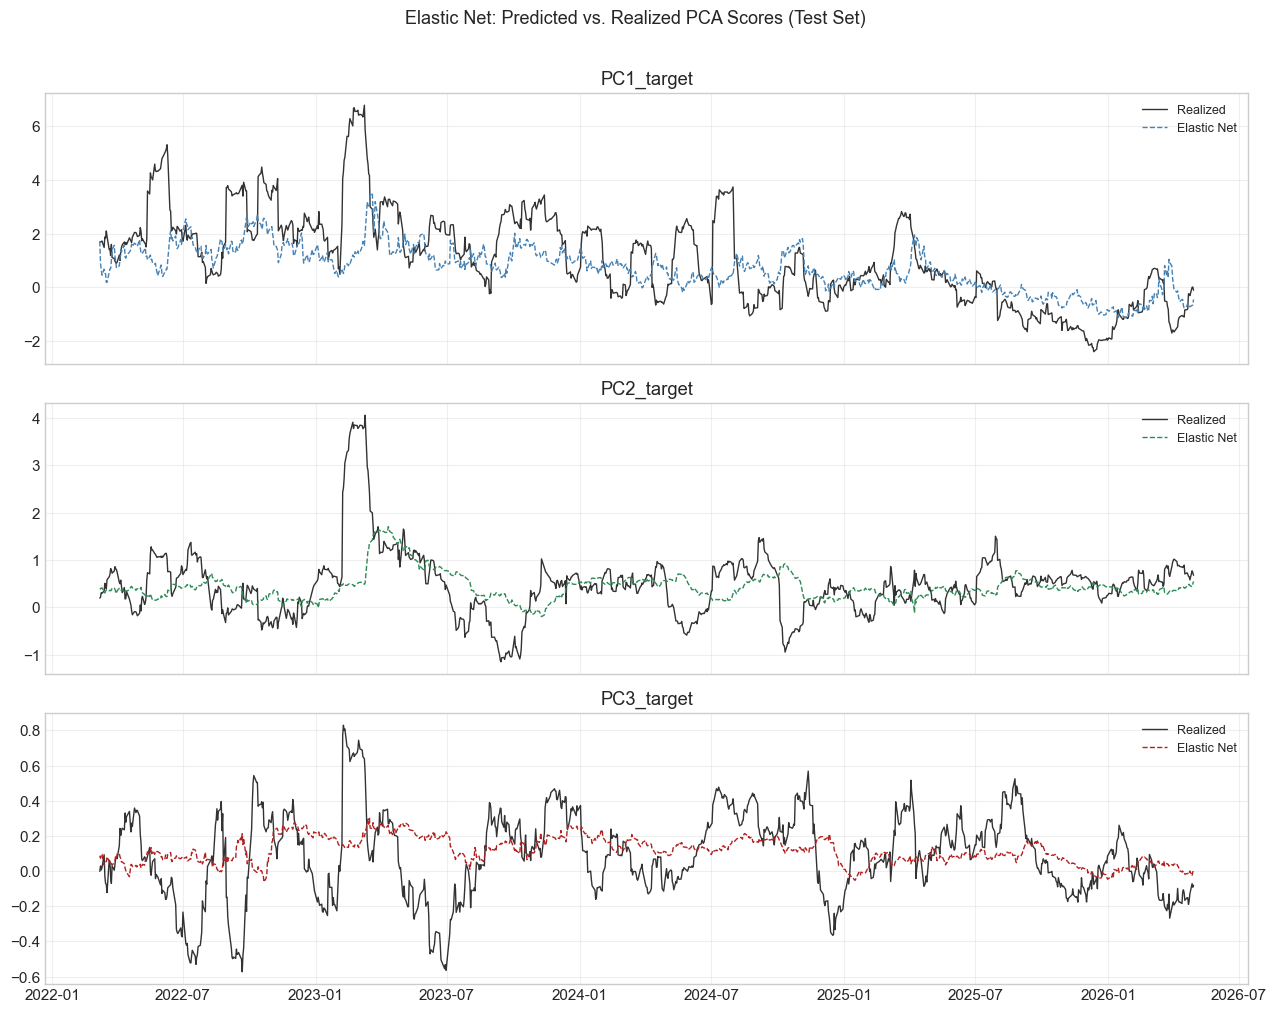

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, target, color in zip(axes, TARGETS, ['steelblue', 'seagreen', 'firebrick']):
    ax.plot(test.index, test[target].values, color='black', lw=1.0, label='Realized', alpha=0.8)
    ax.plot(test.index, results_enet[target]['y_pred_test'],
            color=color, lw=1.0, linestyle='--', label='Elastic Net')
    ax.set_title(target); ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Elastic Net: Predicted vs. Realized PCA Scores (Test Set)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

### 6. Model 2 - Gradient Boosting

Gradient Boosting builds an ensemble of decision trees sequentially, each correcting
the residuals of the previous one. Unlike Elastic Net, it captures non-linear relationships and
interaction effects between features.

Hyperparameters are selected using a grid search and time series cross-validation with. The key
parameters are the number of trees, the learning rate, the tree max depth and the boosting strength.

#### 6.1. Fitting Model

In [18]:
# Step 1
param_grid_fast = {
    'n_estimators': [100],
    'learning_rate': [0.05],
    'max_depth': [3],
    'subsample': [0.8],
    'min_samples_leaf': [20],
}

positive_features = {}
tscv_inner = TimeSeriesSplit(n_splits=5)

for target in TARGETS:
    y_train = train[target]
    sc0 = StandardScaler()
    X_tr_sc0 = sc0.fit_transform(X_train)

    gb0 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                     max_depth=3, subsample=0.8,
                                     min_samples_leaf=20, random_state=RANDOM_STATE)
    gb0.fit(X_tr_sc0, y_train)

    mdi = pd.Series(gb0.feature_importances_, index=FEATURES)

    threshold = mdi.mean()
    selected  = mdi[mdi >= threshold].index.tolist()
    positive_features[target] = selected if len(selected) >= 3 else FEATURES
    print(f'{target}: {len(positive_features[target])}/{len(FEATURES)} features retained ')
    print(f'  Selected: {positive_features[target]}')

# Step 2
param_grid = {
    'n_estimators':    [200, 500],
    'learning_rate':   [0.05, 0.1],
    'max_depth':       [3, 4],
    'min_samples_leaf':[5, 10],
}

results_gb = {}

for target in TARGETS:
    y_train = train[target]
    y_test  = test[target]
    feats   = positive_features[target]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_train[feats])
    X_te_sc = sc.transform(X_test[feats])

    gb_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
    grid     = GridSearchCV(gb_model, param_grid, cv=tscv_inner,
                            scoring='neg_root_mean_squared_error',
                            n_jobs=-1, verbose=0)
    grid.fit(X_tr_sc, y_train)

    best      = grid.best_estimator_
    y_pred_tr = best.predict(X_tr_sc)
    y_pred_te = best.predict(X_te_sc)

    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred_te))
    mae_te  = mean_absolute_error(y_test, y_pred_te)
    gap     = rmse_te / rmse_tr

    results_gb[target] = {
        'best_params': grid.best_params_, 'rmse_train': rmse_tr, 'rmse_test': rmse_te,
        'mae_test': mae_te, 'model': best, 'scaler': sc, 'y_pred_test': y_pred_te,
        'features': feats,
    }

    print(f'\n--- {target} ---')
    print(f'  Features used   : {len(feats)}/{len(FEATURES)}')
    print(f'  Best params     : {grid.best_params_}')
    print(f'  RMSE train      : {rmse_tr:.4f}')
    print(f'  RMSE test       : {rmse_te:.4f}')
    print(f'  Train/test gap  : {gap:.1f}x  {"⚠ overfitting" if gap > 3 else "✓ reasonable"}')
    print(f'  MAE test        : {mae_te:.4f}')

PC1_target: 5/41 features retained 
  Selected: ['slope_5_30', 'MOVE', 'fedfunds', 'baa_spread', 'PC1_zscore']
PC2_target: 11/41 features retained 
  Selected: ['slope_5_30', 'level_10Y', 'rvol_ratio', 'VIX', 'MOVE', 'fedfunds', 'baa_spread', 'fed_lag', 'slope_zscore', 'PC2_lag', 'PC2_har_m']
PC3_target: 9/41 features retained 
  Selected: ['slope_2_10', 'slope_5_30', 'level_10Y', 'rvol_ratio', 'fed_lag', 'slope_zscore', 'PC3_zscore', 'PC3_lag', 'PC2_har_m']

--- PC1_target ---
  Features used   : 5/41
  Best params     : {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200}
  RMSE train      : 0.5424
  RMSE test       : 1.4372
  Train/test gap  : 2.6x  ✓ reasonable
  MAE test        : 1.1728

--- PC2_target ---
  Features used   : 11/41
  Best params     : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200}
  RMSE train      : 0.2932
  RMSE test       : 0.8257
  Train/test gap  : 2.8x  ✓ reasonable
  MAE test        : 0.61

#### 6.2. Gradient Boosting Predictions vs. Realized

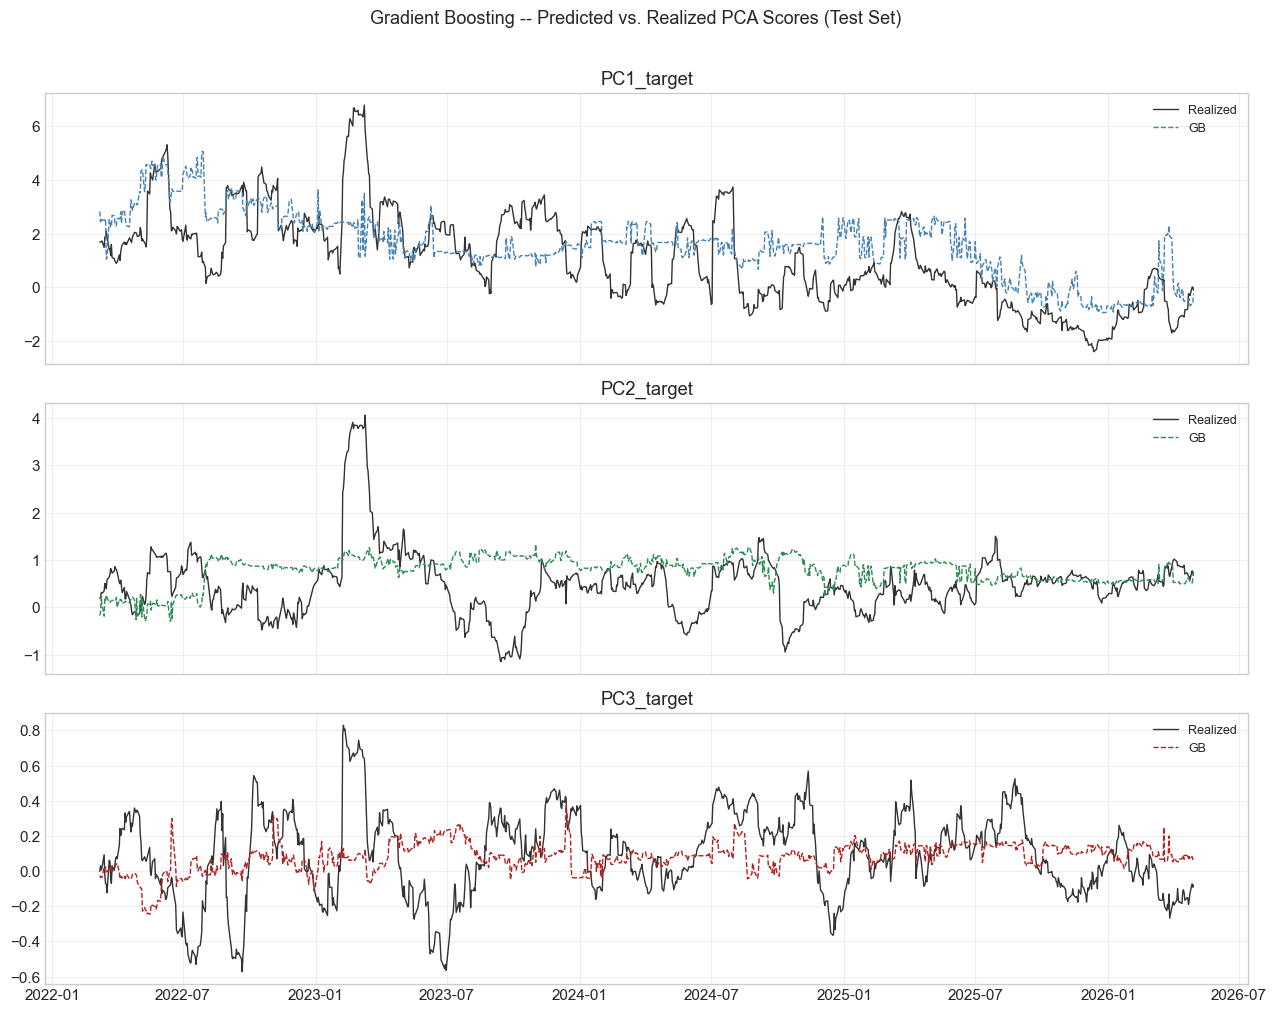

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, target, color in zip(axes, TARGETS, ['steelblue', 'seagreen', 'firebrick']):
    ax.plot(test.index, test[target].values, color='black', lw=1.0, label='Realized', alpha=0.8)
    ax.plot(test.index, results_gb[target]['y_pred_test'],
            color=color, lw=1.0, linestyle='--', label='GB')
    ax.set_title(target); ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Gradient Boosting -- Predicted vs. Realized PCA Scores (Test Set)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

#### 6.3. Model Comparison -- Elastic Net vs. Gradient Boosting

In [20]:
print('=' * 65 + '\n MODEL COMPARISON (TEST SET):\n' + '=' * 65)
print(f"  {'Target':<15} {'ENet RMSE':>11} {'GB RMSE':>10} {'ENet MAE':>11} {'GB MAE':>8}")
print(f"  {'-'*57}")
for t in TARGETS:
    e = results_enet[t]; g = results_gb[t]
    print(f"  {t:<15} {e['rmse_test']:>11.4f} {g['rmse_test']:>10.4f} "
          f"{e['mae_test']:>11.4f} {g['mae_test']:>8.4f}")

 MODEL COMPARISON (TEST SET):
  Target            ENet RMSE    GB RMSE    ENet MAE   GB MAE
  ---------------------------------------------------------
  PC1_target           1.3987     1.4372      1.0270   1.1728
  PC2_target           0.6620     0.8257      0.4377   0.6154
  PC3_target           0.2469     0.2485      0.1907   0.1991


### 7. Permutation Importance (GB)

We now study which feature is the most important for each targets' Gradient Boosting fitted model. This allow to identify what are the drivers of the volatility term structure level, slope, and curvature.

#### 7.1. Permutation Importance by Component

In [21]:
importance_results = {}

for target in TARGETS:
    model  = results_gb[target]['model']
    scaler = results_gb[target]['scaler']
    feats  = results_gb[target]['features']
    X_te_sc = scaler.transform(X_test[feats])
    y_test  = test[target]

    perm = permutation_importance(
        model, X_te_sc, y_test,
        n_repeats=30, random_state=RANDOM_STATE,
        scoring='neg_root_mean_squared_error'
    )
    imp_df = pd.DataFrame({
        'feature':         feats,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
    }).sort_values('importance_mean', ascending=False)

    importance_results[target] = imp_df

    print(f'--- {target} ---')
    print(imp_df.to_string(index=False))
    print()


--- PC1_target ---
   feature  importance_mean  importance_std
      MOVE         0.734571        0.027389
  fedfunds         0.153963        0.024098
PC1_zscore         0.152363        0.015197
baa_spread         0.024098        0.012403
slope_5_30        -0.026643        0.004531

--- PC2_target ---
     feature  importance_mean  importance_std
     fed_lag         0.050578        0.003158
     PC2_lag         0.020380        0.002008
    fedfunds         0.019887        0.009228
         VIX         0.013205        0.001719
  rvol_ratio         0.004675        0.001031
  baa_spread         0.004035        0.000684
   level_10Y         0.000578        0.000485
        MOVE        -0.002360        0.003697
slope_zscore        -0.002722        0.000642
   PC2_har_m        -0.003011        0.001988
  slope_5_30        -0.004543        0.001420

--- PC3_target ---
     feature  importance_mean  importance_std
     fed_lag         0.010255        0.001248
slope_zscore         0.009819    

#### 7.2. Permutation Importance by Component (Cont'd)

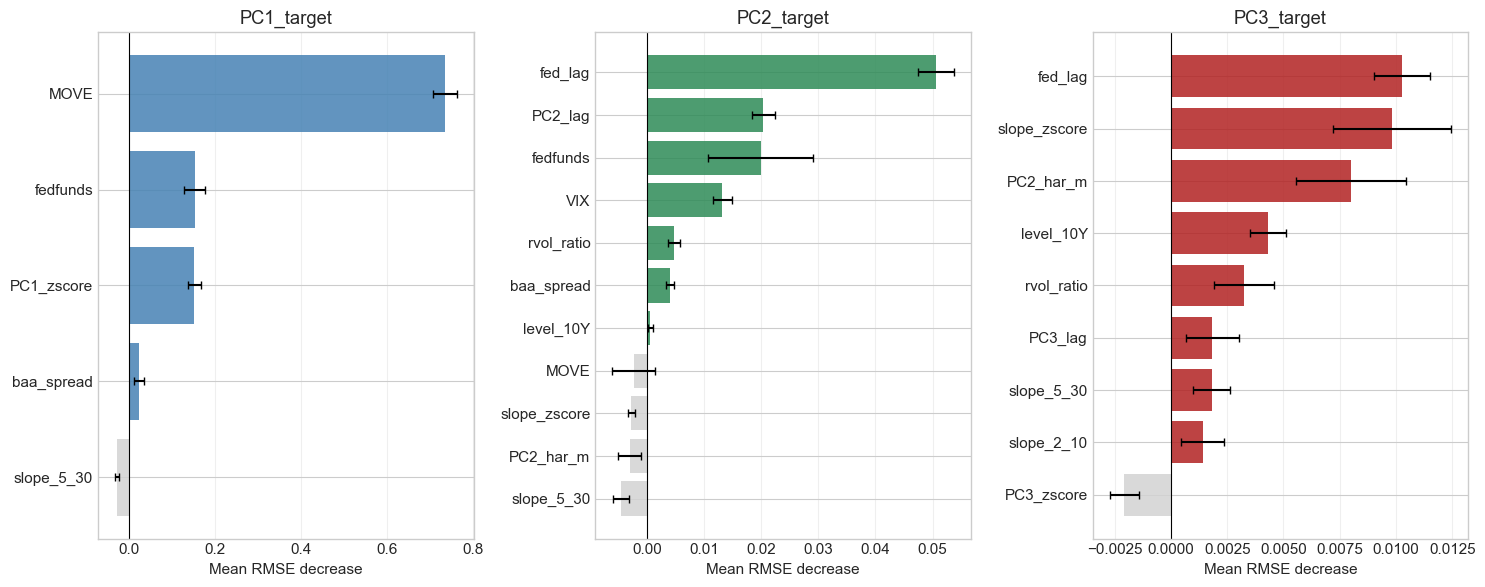

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, target, color in zip(axes, TARGETS, ['steelblue', 'seagreen', 'firebrick']):
    imp = importance_results[target].sort_values('importance_mean')
    bar_colors = [color if v > 0 else 'lightgray' for v in imp['importance_mean']]
    ax.barh(imp['feature'], imp['importance_mean'], color=bar_colors,
            xerr=imp['importance_std'], alpha=0.85, capsize=3)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(target)
    ax.set_xlabel('Mean RMSE decrease')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 8. Walk-Forward Validation

Walk-forward validation replicates the real use case: at each step, the model is trained on all available history and evaluated on the next unseen window. We apply the walk-forward to the two models, Elastic Net and Gradient Boosting.

#### 8.1. Walk-Forward Results

In [23]:
results_wf  = {t: {'enet': [], 'gb': []} for t in TARGETS}
tscv_wf     = TimeSeriesSplit(n_splits=N_SPLITS)
X_all       = df_model[FEATURES]
Y_all       = df_model[TARGETS]

for fold, (train_idx, test_idx) in enumerate(tscv_wf.split(X_all)):
    X_tr = X_all.iloc[train_idx]
    X_te = X_all.iloc[test_idx]

    for target in TARGETS:
        y_tr = Y_all[target].iloc[train_idx]
        y_te = Y_all[target].iloc[test_idx]

        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)

        # Elastic Net
        enet = ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
            cv=TimeSeriesSplit(n_splits=3), max_iter=10000, random_state=RANDOM_STATE
        )
        enet.fit(X_tr_sc, y_tr)
        rmse_e = np.sqrt(mean_squared_error(y_te, enet.predict(X_te_sc)))
        results_wf[target]['enet'].append(rmse_e)

        # Gradient Boosting
        best_p = results_gb[target]['best_params']
        gb = GradientBoostingRegressor(**best_p, random_state=RANDOM_STATE)
        gb.fit(X_tr_sc, y_tr)
        rmse_g = np.sqrt(mean_squared_error(y_te, gb.predict(X_te_sc)))
        results_wf[target]['gb'].append(rmse_g)

print('=' * 55 + '\n WALK-FORWARD RESULTS:\n' + '=' * 55)
print(f"  {'Target':<15} {'ENet':>10} {'GB':>10}")
print(f"  {'-'*38}")
for t in TARGETS:
    em = np.mean(results_wf[t]['enet'])
    gm = np.mean(results_wf[t]['gb'])
    print(f'  {t:<15} {em:>10.4f} {gm:>10.4f}')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.369e-03, tolerance: 2.161e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.567e-03, tolerance: 2.161e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

 WALK-FORWARD RESULTS:
  Target                ENet         GB
  --------------------------------------
  PC1_target          1.8516     1.8489
  PC2_target          0.6629     0.7965
  PC3_target          0.2732     0.3374


#### 8.2. Walk-Forward RMSE per Fold

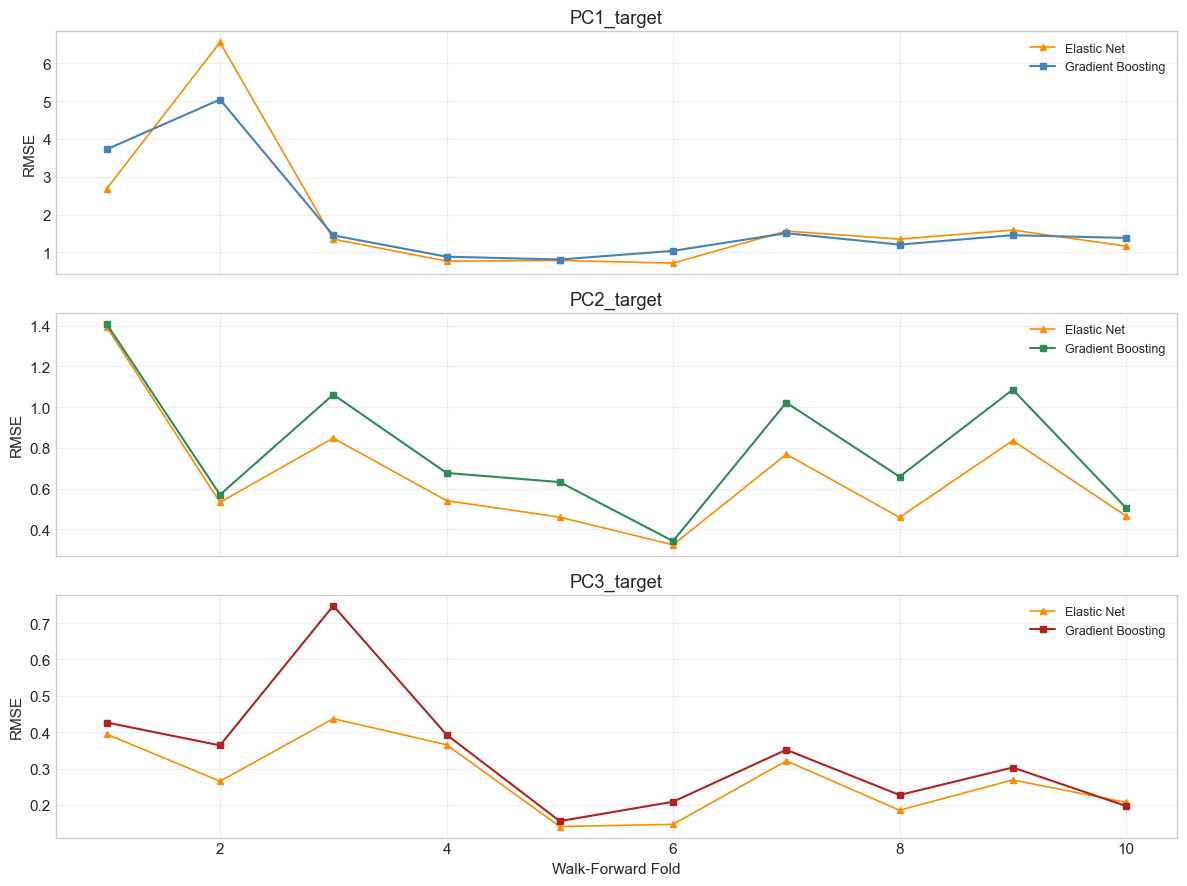

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
folds = np.arange(1, N_SPLITS + 1)

for ax, target, color in zip(axes, TARGETS, ['steelblue', 'seagreen', 'firebrick']):
    ax.plot(folds, results_wf[target]['enet'], '^-', color='darkorange',
            lw=1.2, markersize=5, label='Elastic Net')
    ax.plot(folds, results_wf[target]['gb'], 's-', color=color,
            lw=1.5, markersize=5, label='Gradient Boosting')
    ax.set_title(target)
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Walk-Forward Fold')

plt.tight_layout()
plt.show()

#### 8.3. Model Quality Assessment

Raw RMSE is hard to interpret. To interpret the result and choose the best model, we use three metrics:

- **Persistence baseline**: predicts the persistence. In autocorrelated time series this is a strong benchmark.
- **Skill score**: $1 - (\text{Model RMSE} / \text{Persistence RMSE}$. If positive the model beats the naive forecast, if negative it is worth than baseline prediction.
- **Information Coefficient (IC)**: Spearman rank correlation between predicted and realized values. A model that is not precise, but correctly classify high vs low volatility period will show positive IC.


In [25]:
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

persistence = {}
for target, pc in zip(TARGETS, ['PC1', 'PC2', 'PC3']):
    y_true_p = test[target]; pc_now = df_pca[pc].reindex(test.index)
    valid = y_true_p.notna() & pc_now.notna()
    persistence[target] = np.sqrt(mean_squared_error(y_true_p[valid], pc_now[valid]))

print('=' * 70 + '\n MODEL QUALITY ASSESSMENT (TEST SET):\n' + '=' * 70)
print(f"  {'Target':<15} {'Persist.':>10} {'ENet RMSE':>11} {'ENet R2':>9} {'GB RMSE':>9} {'GB R2':>7}")
print(f"  {'-'*57}")
for target in TARGETS:
    y_true = test[target].dropna()
    rmse_p = persistence[target]
    ye = pd.Series(results_enet[target]['y_pred_test'], index=test.index).reindex(y_true.index).dropna()
    yg = pd.Series(results_gb[target]['y_pred_test'],   index=test.index).reindex(y_true.index).dropna()
    r2_e = r2_score(y_true.loc[ye.index], ye)
    r2_g = r2_score(y_true.loc[yg.index], yg)
    print(f'  {target:<15} {rmse_p:>10.4f} {results_enet[target]["rmse_test"]:>11.4f} {r2_e:>9.3f} '
          f'{results_gb[target]["rmse_test"]:>9.4f} {r2_g:>7.3f}')
print()
print('  Skill score = 1 - (Model RMSE / Persistence RMSE)')
print(f"  {'Target':<15} {'ENet':>10} {'GB':>10}")
print(f"  {'-'*38}")
for target in TARGETS:
    rmse_p = persistence[target]
    print(f'  {target:<15} {1 - results_enet[target]["rmse_test"]/rmse_p:>10.3f} '
          f'{1 - results_gb[target]["rmse_test"]/rmse_p:>10.3f}')
print()
print('  Information Coefficient (Spearman rank corr, test set):')
print(f"  {'Target':<15} {'ENet IC':>10} {'GB IC':>10}")
print(f"  {'-'*38}")
for target in TARGETS:
    y_true = test[target].dropna()
    ye = pd.Series(results_enet[target]['y_pred_test'], index=test.index).reindex(y_true.index).dropna()
    yg = pd.Series(results_gb[target]['y_pred_test'],   index=test.index).reindex(y_true.index).dropna()
    valid = y_true.index.intersection(ye.index).intersection(yg.index)
    ic_e = spearmanr(ye[valid], y_true[valid]).statistic
    ic_g = spearmanr(yg[valid], y_true[valid]).statistic
    print(f'  {target:<15} {ic_e:>10.3f} {ic_g:>10.3f}')

 MODEL QUALITY ASSESSMENT (TEST SET):
  Target            Persist.   ENet RMSE   ENet R2   GB RMSE   GB R2
  ---------------------------------------------------------
  PC1_target          1.7198      1.3987     0.327    1.4372   0.290
  PC2_target          0.7878      0.6620     0.065    0.8257  -0.455
  PC3_target          0.3152      0.2469    -0.056    0.2485  -0.070

  Skill score = 1 - (Model RMSE / Persistence RMSE)
  Target                ENet         GB
  --------------------------------------
  PC1_target           0.187      0.164
  PC2_target           0.160     -0.048
  PC3_target           0.217      0.212

  Information Coefficient (Spearman rank corr, test set):
  Target             ENet IC      GB IC
  --------------------------------------
  PC1_target           0.649      0.598
  PC2_target           0.231     -0.207
  PC3_target           0.122      0.064


#### 8.4. Per-Component Model Selection

The two models are compared per component: Elastic Net (linear, regularised) vs Gradient Boosting (non-linear). The Information Coefficient drives the selection.

In [26]:
from scipy.stats import spearmanr

ic_comparison = {}
for target in TARGETS:
    y_true = test[target].dropna()
    ye = pd.Series(results_enet[target]['y_pred_test'], index=test.index).reindex(y_true.index).dropna()
    yg = pd.Series(results_gb[target]['y_pred_test'],   index=test.index).reindex(y_true.index).dropna()
    valid = y_true.index.intersection(ye.index).intersection(yg.index)
    ic_comparison[target] = {
        'enet': spearmanr(ye[valid], y_true[valid]).statistic,
        'gb':   spearmanr(yg[valid], y_true[valid]).statistic,
    }

print('=' * 58 + '\n MODEL SELECTION BY COMPONENT (based on IC):\n' + '=' * 58)
print(f"  {'Target':<15} {'ENet IC':>10} {'GB IC':>10} {'Selected':>12}")
print(f"  {'-'*50}")

best_model_choice = {}
best_predictions  = {}

for target in TARGETS:
    ic_e = ic_comparison[target]['enet']
    ic_g = ic_comparison[target]['gb']
    winner = 'GB' if ic_g > ic_e else 'ENet'
    best_model_choice[target] = winner
    best_predictions[target]  = (results_gb[target]['y_pred_test'] if winner == 'GB'
                                  else results_enet[target]['y_pred_test'])
    print(f'  {target:<15} {ic_e:>10.3f} {ic_g:>10.3f} {winner:>12}')
print()
print('  Best predictions assembled for downstream reconstruction and diagnostics.')

 MODEL SELECTION BY COMPONENT (based on IC):
  Target             ENet IC      GB IC     Selected
  --------------------------------------------------
  PC1_target           0.649      0.598         ENet
  PC2_target           0.231     -0.207         ENet
  PC3_target           0.122      0.064         ENet

  Best predictions assembled for downstream reconstruction and diagnostics.


#### 8.5. Scatter Plot: Predicted vs. Realized

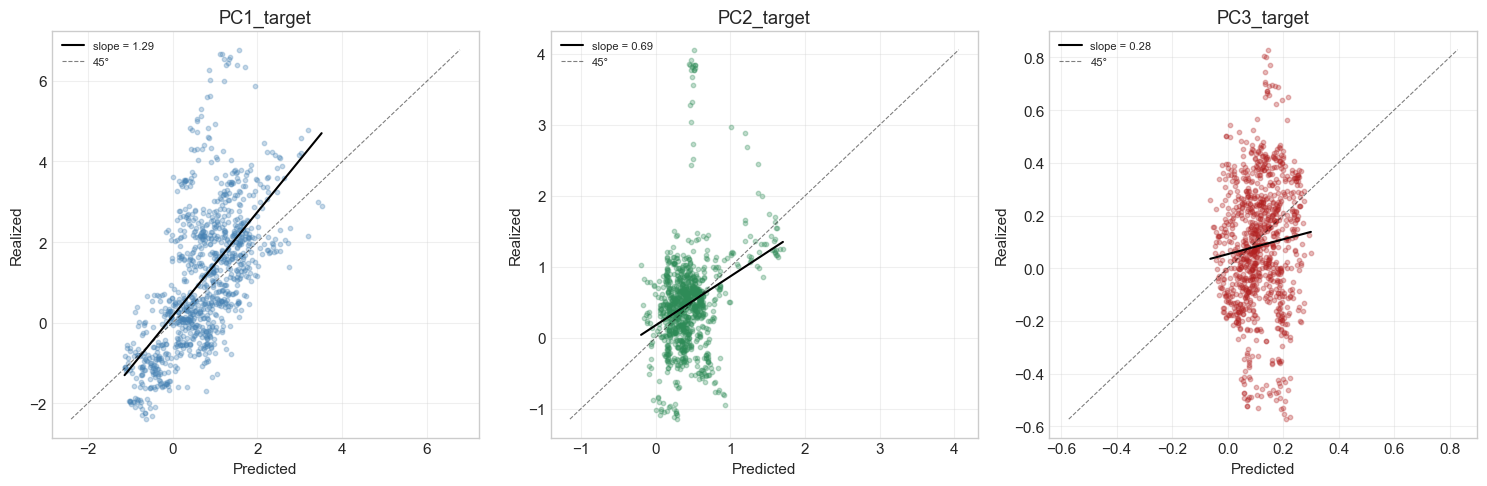

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'firebrick']

for ax, target, color in zip(axes, TARGETS, colors):
    y_true = test[target].dropna()
    y_pred = pd.Series(best_predictions[target], index=test.index).reindex(y_true.index).dropna()
    valid  = y_true.index.intersection(y_pred.index)

    ax.scatter(y_pred[valid], y_true[valid], alpha=0.3, s=10, color=color)

    m, b = np.polyfit(y_pred[valid], y_true[valid], 1)
    x_range = np.linspace(y_pred[valid].min(), y_pred[valid].max(), 100)
    ax.plot(x_range, m * x_range + b, color='black', lw=1.5,
            label=f'slope = {m:.2f}')

    lims = [min(y_pred[valid].min(), y_true[valid].min()),
            max(y_pred[valid].max(), y_true[valid].max())]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='45°')

    ic = ic_comparison[target]['enet']
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Realized')
    ax.set_title(f'{target}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 8.6. Directional Accuracy and ROC-AUC

For a trading desk, the most actionable question is not "how close is the prediction?" but "does the model call the direction correctly?" We define direction as: will the vol term structure level (PC) be **above its current level** in 20 days?

- **Directional accuracy**: fraction of correct calls (random baseline = 50%)
- **ROC-AUC**: measures the model's ability to rank up-moves above down-moves using the raw regression score as a discriminator (random baseline = 0.500)

 DIRECTIONAL ACCURACY AND ROC-AUC (TEST SET)
  Target            Accuracy    ROC-AUC   Up moves    Model
  -------------------------------------------------------
  PC1_target      ✓   72.5%        0.784      46.5%     ENet
  PC2_target      ✓   70.9%        0.782      51.4%     ENet
  PC3_target      ✓   68.7%        0.777      47.9%     ENet

  Random baseline: Accuracy = 50.0%  |  ROC-AUC = 0.500


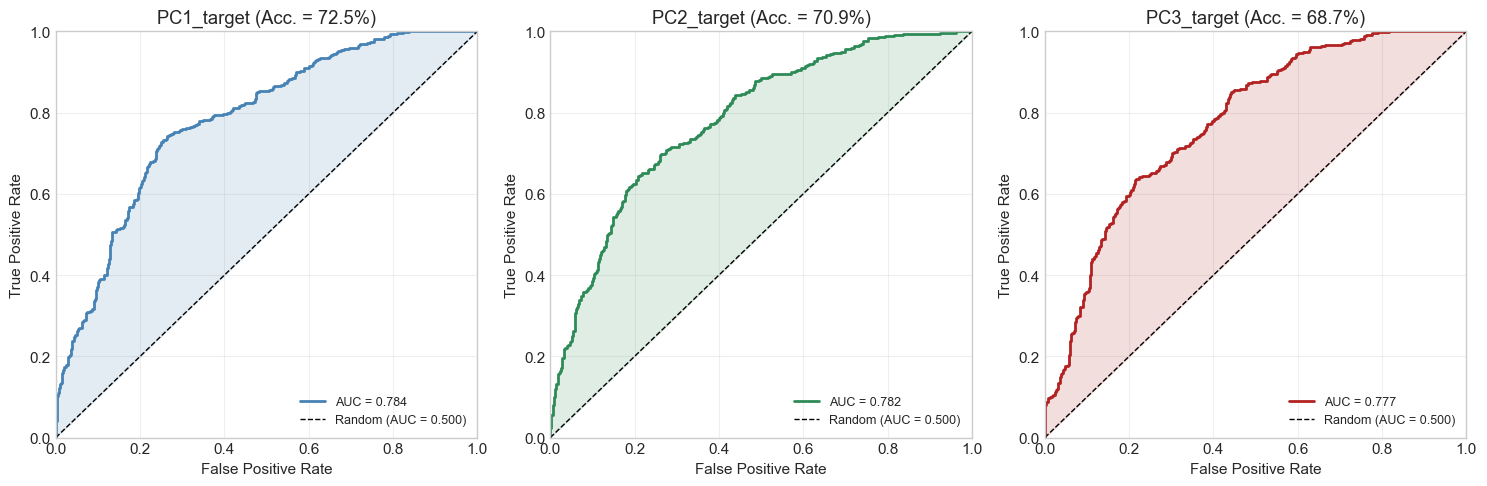

In [52]:
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

print('=' * 70)
print(' DIRECTIONAL ACCURACY AND ROC-AUC (TEST SET)')
print('=' * 70)
print(f"  {'Target':<15} {'Accuracy':>10} {'ROC-AUC':>10} {'Up moves':>10} {'Model':>8}")
print(f"  {'-'*55}")

dir_results = {}

for target, pc in zip(TARGETS, ['PC1', 'PC2', 'PC3']):
    y_true = test[target].dropna()
    pc_now = df_pca[pc].reindex(test.index).reindex(y_true.index)
    y_pred = pd.Series(best_predictions[target], index=test.index).reindex(y_true.index)
    valid  = y_true.notna() & pc_now.notna() & y_pred.notna()

    dir_true = (y_true[valid] > pc_now[valid]).astype(int)
    score    = (y_pred[valid] - pc_now[valid]).values
    dir_pred = (score > 0).astype(int)

    acc  = accuracy_score(dir_true, dir_pred)
    try:
        auc = roc_auc_score(dir_true, score)
    except Exception:
        auc = float('nan')

    pct_up = dir_true.sum() / len(dir_true)
    winner = best_model_choice[target]
    dir_results[target] = {'accuracy': acc, 'auc': auc, 'pct_up': pct_up,
                            'dir_true': dir_true, 'score': score}

    flag = '✓' if acc > 0.52 else '~'
    print(f'  {target:<15} {flag} {acc:>7.1%} {auc:>12.3f} {pct_up:>10.1%} {winner:>8}')

print()
print('  Random baseline: Accuracy = 50.0%  |  ROC-AUC = 0.500')

# ROC AUC
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'firebrick']

for ax, target, color in zip(axes, TARGETS, colors):
    fpr, tpr, _ = roc_curve(dir_results[target]['dir_true'],
                             dir_results[target]['score'])
    auc   = dir_results[target]['auc']
    acc   = dir_results[target]['accuracy']
    model = best_model_choice[target]

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.3f}')
    ax.fill_between(fpr, tpr, fpr, alpha=0.15, color=color)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{target} (Acc. = {acc:.1%})')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

### 9. Vol Curve Reconstruction

#### 9.1. Inverting PCA Predictions

The three predicted PCA scores can be mapped back to the original tenor space by applying
the inverse PCA transform followed by the inverse standardization. This gives a predicted
realized volatility curve across tenors at J+20.

In [28]:
# Inverse transform
PC_preds = np.column_stack([best_predictions[t] for t in TARGETS])

vol_reconstructed = scaler_pca.inverse_transform(pca.inverse_transform(PC_preds))
df_vol_recon = pd.DataFrame(
    vol_reconstructed,
    index=test.index,
    columns=['vol_2Y_pred', 'vol_5Y_pred', 'vol_10Y_pred', 'vol_30Y_pred']
)

vol_actual = df[VOL_COLS].reindex(test.index)

print('=' * 50 + '\n RECONSTRUCTION RMSE BY TENOR:\n' + '=' * 50)
for pred_col, act_col, tenor in zip(
    df_vol_recon.columns, VOL_COLS, ['2Y', '5Y', '10Y', '30Y']
):
    valid = vol_actual[act_col].notna() & df_vol_recon[pred_col].notna()
    rmse  = np.sqrt(mean_squared_error(vol_actual[act_col][valid], df_vol_recon[pred_col][valid]))
    print(f'  {tenor}  RMSE: {rmse:.4f}')


 RECONSTRUCTION RMSE BY TENOR:
  2Y  RMSE: 0.0201
  5Y  RMSE: 0.0168
  10Y  RMSE: 0.0140
  30Y  RMSE: 0.0110


#### 9.2. Predicted vs. Realized Vol by Tenor (Test Set)

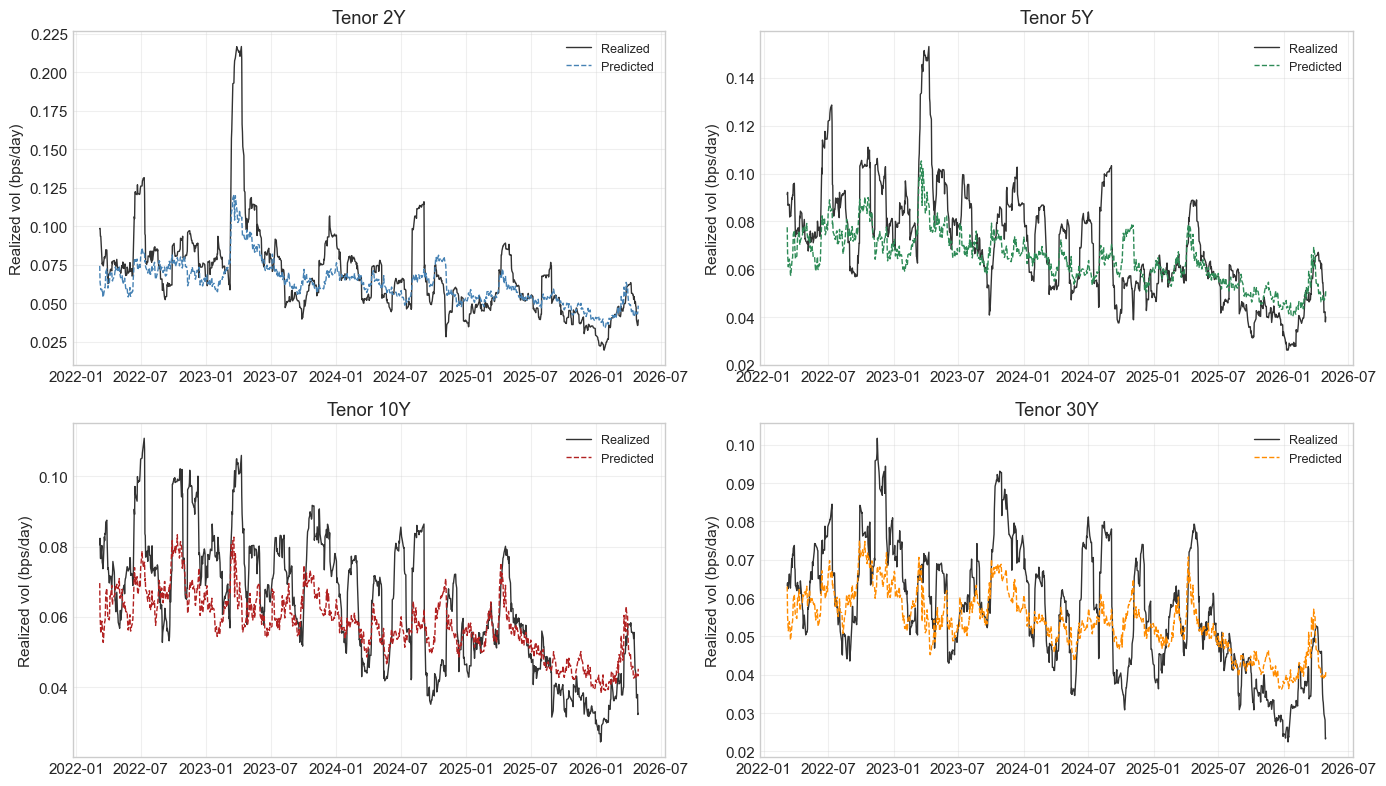

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, pred_col, act_col, tenor, color in zip(
    axes.flatten(),
    df_vol_recon.columns, VOL_COLS,
    ['2Y', '5Y', '10Y', '30Y'],
    ['steelblue', 'seagreen', 'firebrick', 'darkorange']
):
    ax.plot(test.index, vol_actual[act_col].values, color='black',
            lw=1.0, alpha=0.8, label='Realized')
    ax.plot(test.index, df_vol_recon[pred_col].values, color=color,
            lw=1.0, linestyle='--', label='Predicted')
    ax.set_title(f'Tenor {tenor}')
    ax.set_ylabel('Realized vol (bps/day)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 10. Diagnostics and Robustness

#### 10.1. Residual Analysis

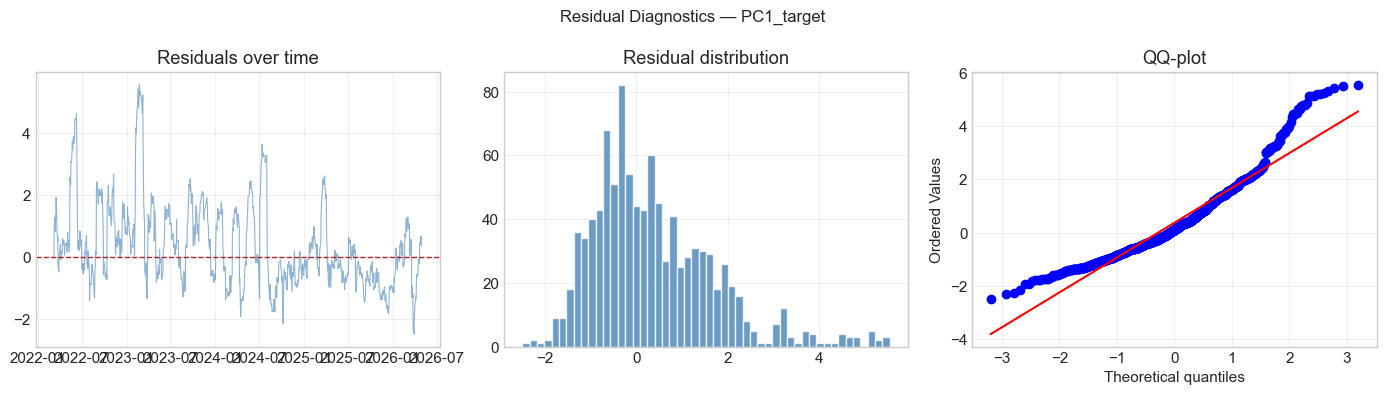

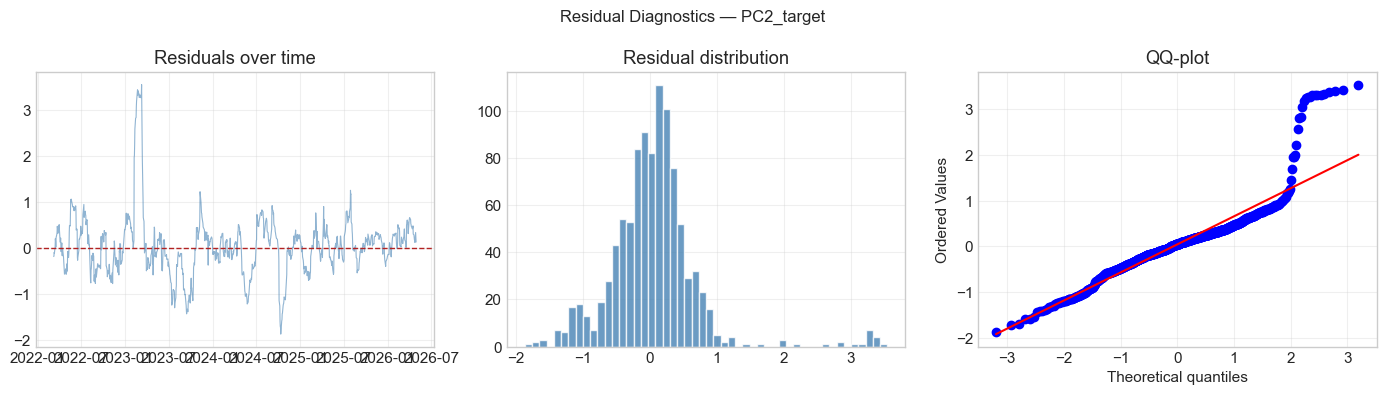

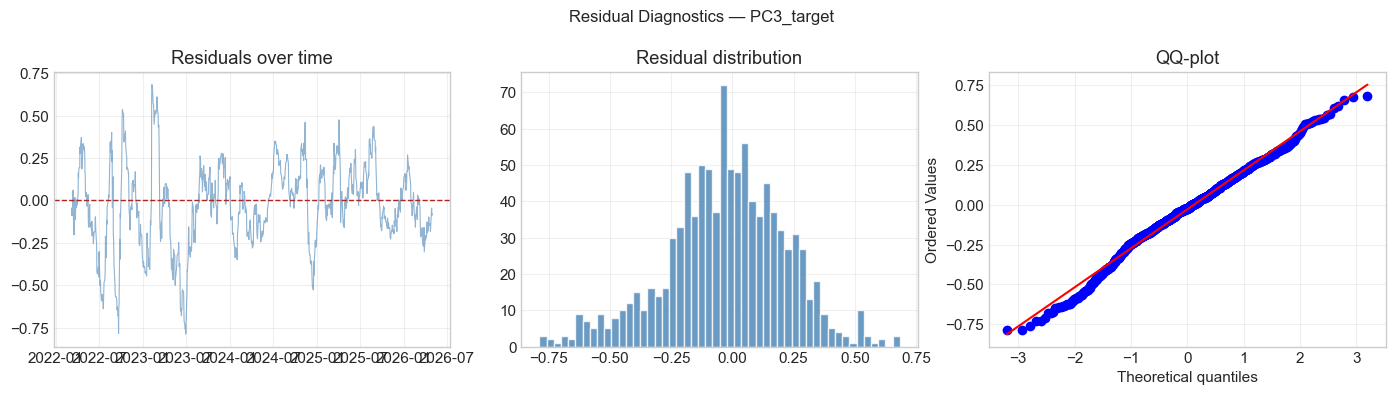

In [30]:
for target in TARGETS:
    y_actual = test[target].values
    y_pred   = best_predictions[target]
    residuals = y_actual - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(test.index, residuals, alpha=0.6, color='steelblue', lw=0.8)
    axes[0].axhline(0, color='firebrick', lw=1.0, linestyle='--')
    axes[0].set_title('Residuals over time')
    axes[0].grid(alpha=0.3)

    axes[1].hist(residuals, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[1].set_title('Residual distribution')
    axes[1].grid(alpha=0.3)

    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title('QQ-plot')
    axes[2].grid(alpha=0.3)

    plt.suptitle(f'Residual Diagnostics — {target}', fontsize=12)
    plt.tight_layout()
    plt.show()

#### 10.2. Performance by Market Regime

In [31]:
move_test    = df['MOVE'].reindex(test.index)
stress_mask  = move_test > 100
calm_mask    = move_test < 80

print('=' * 60 + '\n PERFORMANCE BY MARKET REGIME:\n' + '=' * 60)
print(f"  {'Target':<15} {'RMSE (stress)':>14} {'RMSE (calm)':>13} {'Obs stress':>11} {'Obs calm':>9}")
print(f"  {'-'*62}")

for target in TARGETS:
    y_actual  = test[target]
    y_pred    = pd.Series(results_gb[target]['y_pred_test'], index=test.index)

    mask_s = stress_mask & y_actual.notna()
    mask_c = calm_mask   & y_actual.notna()

    rmse_s = np.sqrt(mean_squared_error(y_actual[mask_s], y_pred[mask_s])) if mask_s.sum() > 0 else np.nan
    rmse_c = np.sqrt(mean_squared_error(y_actual[mask_c], y_pred[mask_c])) if mask_c.sum() > 0 else np.nan

    print(f'  {target:<15} {rmse_s:>14.4f} {rmse_c:>13.4f} {mask_s.sum():>11} {mask_c.sum():>9}')

 PERFORMANCE BY MARKET REGIME:
  Target           RMSE (stress)   RMSE (calm)  Obs stress  Obs calm
  --------------------------------------------------------------
  PC1_target              1.5182        0.8779         610       146
  PC2_target              0.9692        0.1900         610       146
  PC3_target              0.2839        0.1805         610       146


In [57]:
print(0.2839/0.1805)

1.5728531855955679
